# Imports


In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


import numpy as np
import pandas as pd

import seaborn as sns
import torch

import re
from itertools import product
from lib.fuse_config import FuseConfig
sns.set_style("whitegrid")
DPI= 1000

do_save = True

## Helpers


In [2]:
## already adds the '<report>/assets/' five the rest
def savefig(path_rest: str, force_save:bool = False, g= None):

  if path_rest[-4:] != ".png":
    path_rest += ".png"

  if g is not None:
    g.tight_layout()
    g.savefig(f"/home/kup/Desktop/code/fyp-report/assets/{path_rest}", format="png", dpi=DPI)
    return 
  
  if force_save or do_save:
    plt.tight_layout()
    plt.savefig(f"/home/kup/Desktop/code/fyp-report/assets/{path_rest}", format="png", dpi=DPI)
    return
  


In [5]:
def combine_multi_file_rep(cfgs: list[FuseConfig], folder: str, file: str, format_name: str ):
  df_avgs = []
  df_alls = []

  for rep in range(3):
    for fuse_config  in cfgs:
      name = format_name.format(file = file, fuse_config = fuse_config, rep = rep)
      
      avg = pd.read_csv(f"{folder}/{name}.csv")
      all = pd.read_csv(f"{folder}/ALL{name}.csv")

      all = all[~all["error"]]
      avg = avg[~avg["error"]]
      df_avgs.append(avg)
      df_alls.append(all)
  all_df = pd.concat(df_alls, ignore_index=True)
  avg_df = pd.concat(df_avgs, ignore_index=True)


  all_df.to_csv(f"{folder}/ALL{file}.csv", )
  avg_df.to_csv(f"{folder}/{file}.csv")

def combine_multi_file_seed(
  cfgs: list[FuseConfig], 
  folder: str, 
  file: str, 
  format_name: str, 
  seeds = [3790,1901,4248,6689,7653]
):
  df_avgs = []
  df_alls = []
    

  for seed in seeds:
    for fuse_config  in cfgs:
      name = format_name.format(file = file, fuse_config = fuse_config, seed = seed)
      
      avg = pd.read_csv(f"{folder}/{name}.csv")
      all = pd.read_csv(f"{folder}/ALL{name}.csv")

      all = all[~all["error"]]
      avg = avg[~avg["error"]]
      df_avgs.append(avg)
      df_alls.append(all)
      
  all_df = pd.concat(df_alls, ignore_index=True)
  avg_df = pd.concat(df_avgs, ignore_index=True)


  all_df.to_csv(f"{folder}/ALL{file}.csv", )
  avg_df.to_csv(f"{folder}/{file}.csv")


In [37]:
def final_and_min_melter(df) -> tuple[pd.DataFrame, pd.DataFrame]:
  df_long = df.melt(
      id_vars=['epochs', 'cam_type', 'config', 'seed'],
      value_vars=[
        'avg_control_final_distance',
        'avg_test_final_distance',
        'avg_control_min_distance',
        'avg_test_min_distance',
      ],
      var_name='condition',
      value_name='distance'
  )
  df_long["condition"] = df_long["condition"].map({
    "avg_control_final_distance": "(control) final", 
    "avg_test_final_distance": "(test) final",
    "avg_control_min_distance": "(control) min", 
    "avg_test_min_distance": "(test) min",
  })


  return df_long[df_long["condition"].str.contains("final")], df_long[df_long["condition"].str.contains("min")]


def done_count_melter(df) -> pd.DataFrame:
  df_long = df.melt(
      id_vars=['epochs', 'cam_type', 'config', 'seed'],
      value_vars=[
        "control_done_count", 
        "test_done_count", 
      ],
      var_name='condition',
      value_name='done_count'
  )
  df_long["condition"] = df_long["condition"].map({
    "control_done_count": "control",
    "test_done_count": "test"
  })


  return df_long

# Fusing Policy Runs


## First big run (set dist demos) 
4/10 small demos were not visible for some reason, and 2/10 wer really small

In [55]:
df_all = pd.read_csv("ZZbig-run-1/ALLvs_random-ns.csv")
df_avg = pd.read_csv("ZZbig-run-1/vs_random-ns.csv")


### plotting the non film

In [56]:
cfgs = [
  FuseConfig.WDLR,
  FuseConfig.WLR_D,
  FuseConfig.DEPTH_FEATS_GATED,
  FuseConfig.DEPTH_FEATS_ATTN,
  FuseConfig.WD_LR,
  FuseConfig.WD_LR_ATTN,
]

df_1_all = df_all[df_all["config"].isin(map(str, cfgs))]
df_1_avg = df_avg[df_avg["config"].isin(map(str, cfgs))]


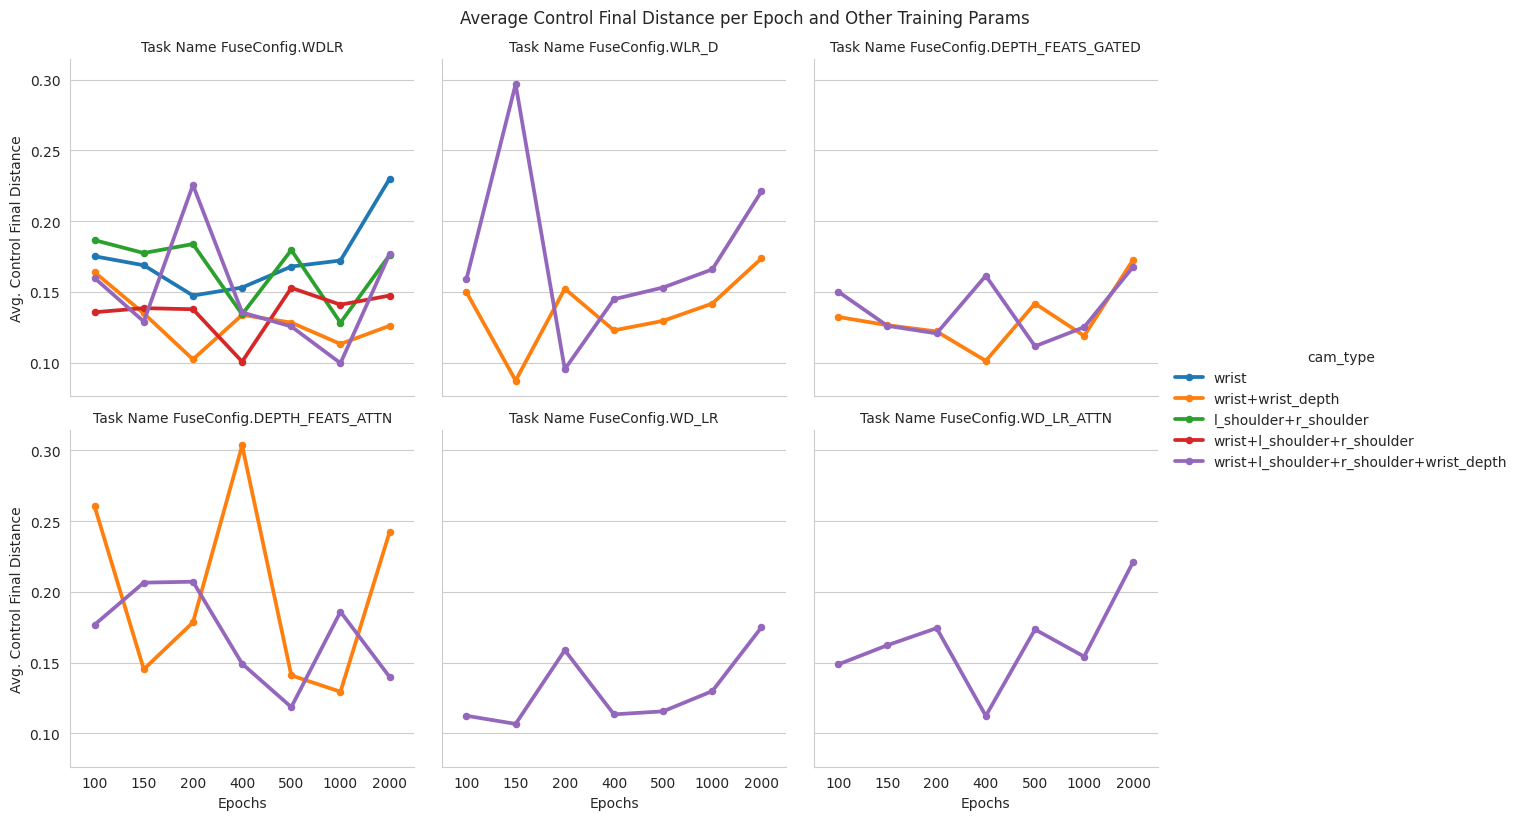

In [64]:
# Plot
g = sns.catplot(
    data=df_1_avg,
    x='epochs',
    y='avg_control_final_distance',
    hue='cam_type',
    col='config',
    col_wrap=3,
    kind="point",
    errorbar=None,
    markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
)

g.set_titles("Task Name {col_name}")
g.set_axis_labels("Epochs", "Avg. Control Final Distance")
g.figure.suptitle("Average Control Final Distance per Epoch and Other Training Params", y=1.02)#
# savefig(f"cam-comb/reach-obs/Z-ro_random-success.png", g = g)
plt.show()


In [91]:
df_1avg_long_final, df_1avg_long_min = final_and_min_melter(df_1_avg)

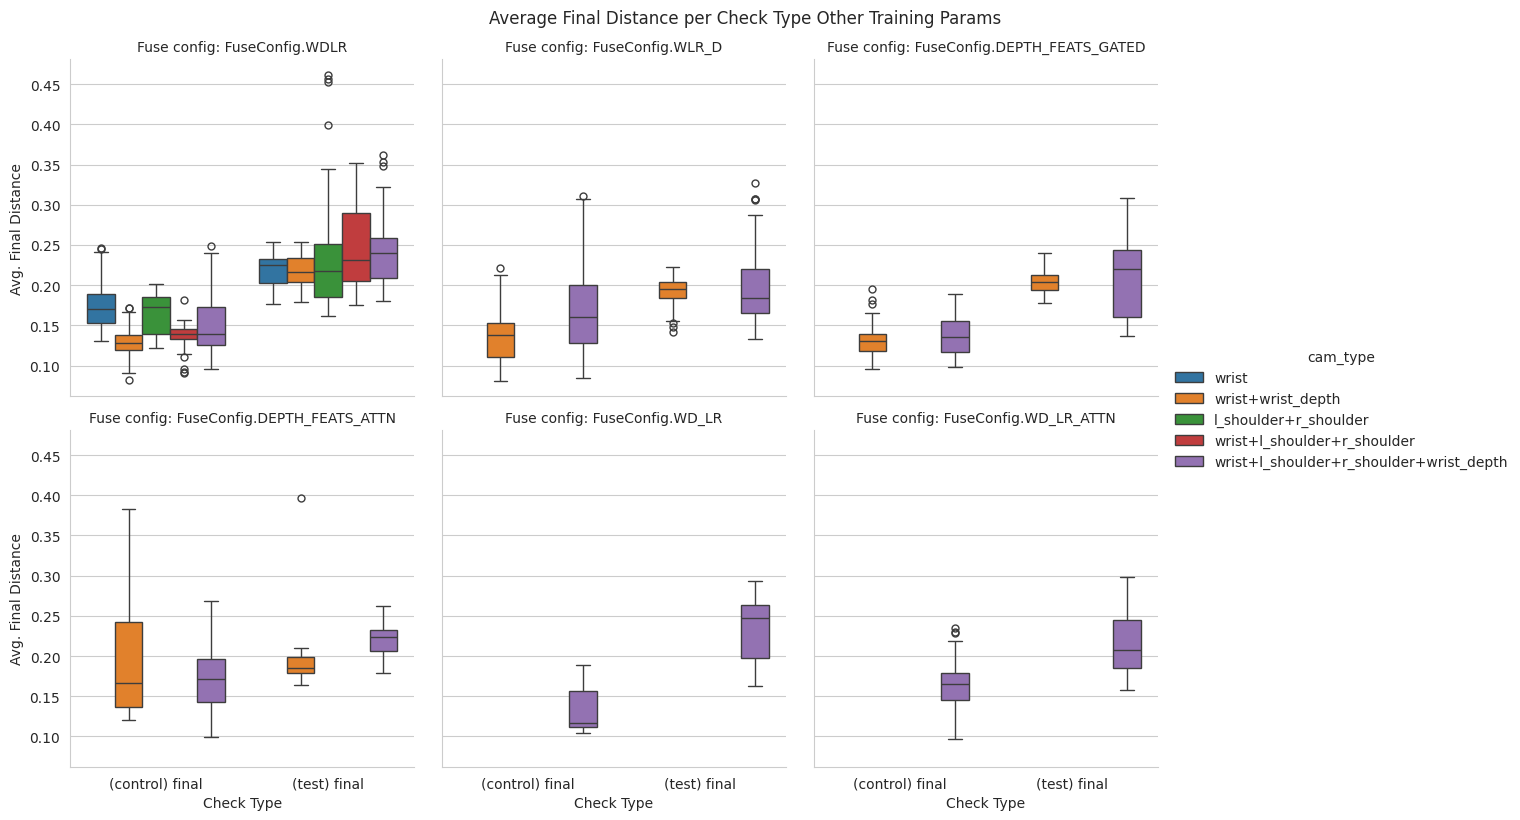

In [92]:
# Plot
g = sns.catplot(
    data=df_1avg_long_final,
    x='condition',
    y='distance',
    hue='cam_type',
    col="config", 
    # row='epochs',
    col_wrap=3,
    kind="box",
    errorbar=None,
    # markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
)

# g.set_titles("Epochs: {row_name}, \n Fuse config: {col_name}")
g.set_titles("Fuse config: {col_name}")
g.set_axis_labels("Check Type", "Avg. Final Distance")
g.figure.suptitle("Average Final Distance per Check Type Other Training Params", y=1.02)#
# savefig(f"cam-comb/reach-obs/Z-ro_random-success.png", g = g)
plt.show()


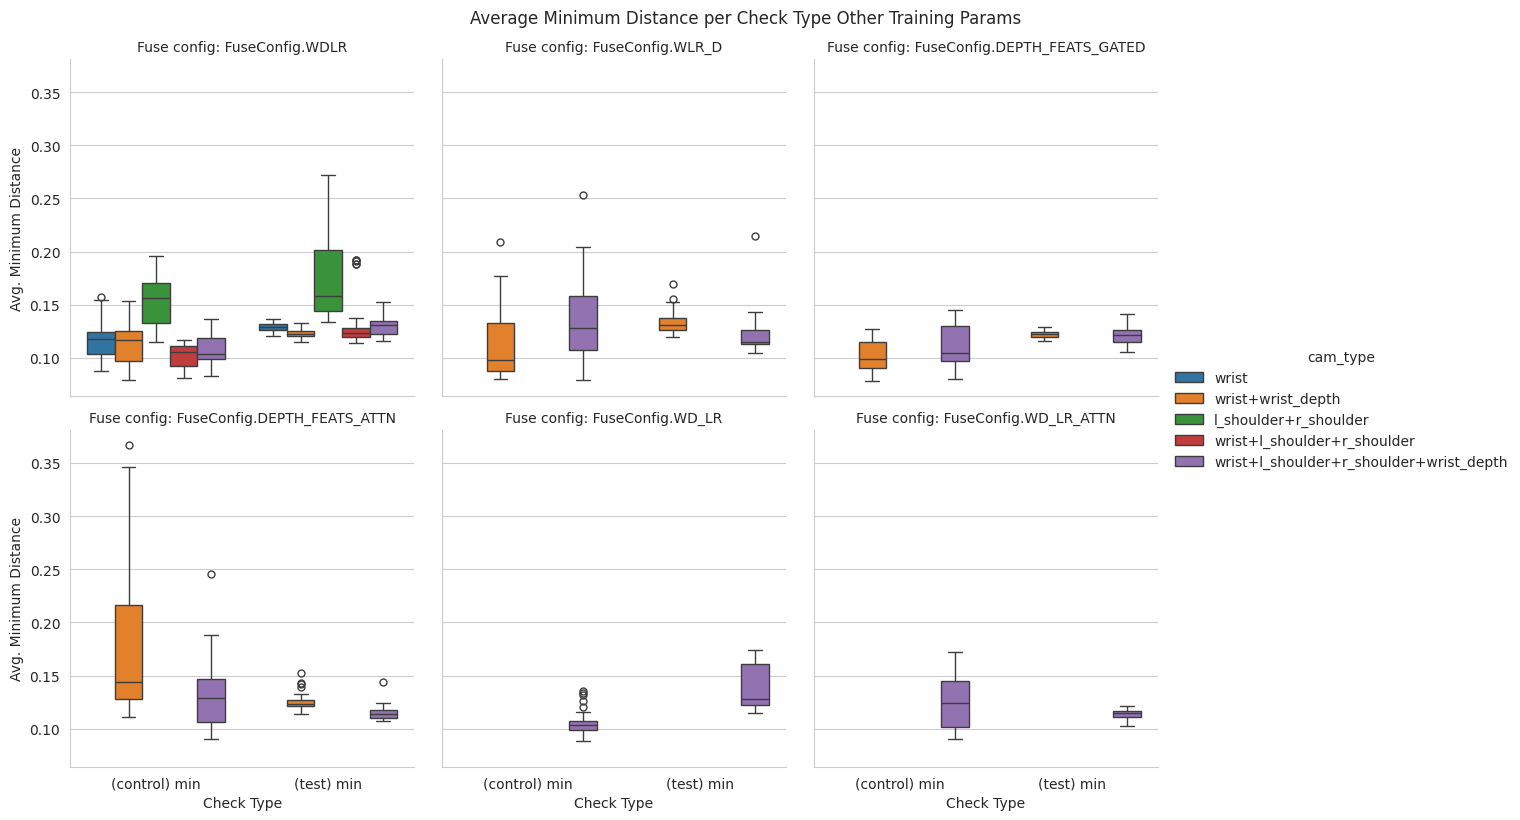

In [93]:
# Plot
g = sns.catplot(
    data=df_1avg_long_min,
    x='condition',
    y='distance',
    hue='cam_type',
    col="config", 
    # row='epochs',
    col_wrap=3,
    kind="box",
    errorbar=None,
    # markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
)

# g.set_titles("Epochs: {row_name}, \n Fuse config: {col_name}")
g.set_titles("Fuse config: {col_name}")
g.set_axis_labels("Check Type", "Avg. Minimum Distance")
g.figure.suptitle("Average Minimum Distance per Check Type Other Training Params", y=1.02)#
# savefig(f"cam-comb/reach-obs/Z-ro_random-success.png", g = g)
plt.show()


### plotting the film

In [52]:
cfgs  =[ 
  FuseConfig.Wfilm_D,
  FuseConfig.W_Dfilm,
  FuseConfig.Wfilm_Dfilm,
]
df_film_all = df_all[df_all["config"].isin(map(str, cfgs))]
df_film_avg = df_avg[df_avg["config"].isin(map(str, cfgs))]
df_film_avg

,Unnamed: 0.1,Unnamed: 0,rep,config,error,task_name,cam_type,epochs,control_done_count,test_done_count,avg_control_final_distance,avg_control_min_distance,avg_test_min_distance,avg_test_final_distance
91,91,1,0,FuseConfig.Wfilm_D,False,Vision_Random,wrist+wrist_depth,100,0.0,0.0,0.280629,0.276401,0.152377,0.193636
92,92,6,0,FuseConfig.Wfilm_D,False,Vision_Random,wrist+wrist_depth,150,0.0,0.0,0.479325,0.371478,0.140643,0.204892
93,93,11,0,FuseConfig.Wfilm_D,False,Vision_Random,wrist+wrist_depth,200,0.0,0.0,0.348067,0.133032,0.141982,0.291147
94,94,16,0,FuseConfig.Wfilm_D,False,Vision_Random,wrist+wrist_depth,400,0.0,0.0,0.365635,0.360892,0.201903,0.203407
95,95,21,0,FuseConfig.Wfilm_D,False,Vision_Random,wrist+wrist_depth,500,0.0,0.0,0.156872,0.126121,0.120530,0.195172
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555,555,11,4,FuseConfig.Wfilm_Dfilm,False,Vision_Random,wrist+wrist_depth,200,0.0,0.0,0.292095,0.268518,0.124259,0.179419
556,556,16,4,FuseConfig.Wfilm_Dfilm,False,Vision_Random,wrist+wrist_depth,400,3.0,0.0,0.150535,0.127302,0.123981,0.224422
557,557,21,4,FuseConfig.Wfilm_Dfilm,False,Vision_Random,wrist+wrist_depth,500,1.0,0.0,0.182567,0.174499,0.127654,0.224672
558,558,26,4,FuseConfig.Wfilm_Dfilm,False,Vision_Random,wrist+wrist_depth,1000,0.0,0.0,0.189146,0.175817,0.126348,0.190686


## Big Run 2
the big boys 4 way ATTN and film are ran here

In [94]:
df_all = pd.read_csv("ZZbig-run-2/ALLvs_random-ns.csv")
df_avg = pd.read_csv("ZZbig-run-2/vs_random-ns.csv")

In [106]:
cfgs = [
  FuseConfig.W_D_L_R_FILM,
  FuseConfig.W_D_L_R_ATTN,
]

df_film_all = df_all[df_all["config"].isin(map(str, cfgs))]
df_film_avg = df_avg[df_avg["config"].isin(map(str, cfgs))]
df_film_avg_long_final, df_film_avg_long_min = final_and_min_melter(df_film_avg)
df_film_avg_dones = done_count_melter(df_film_avg)

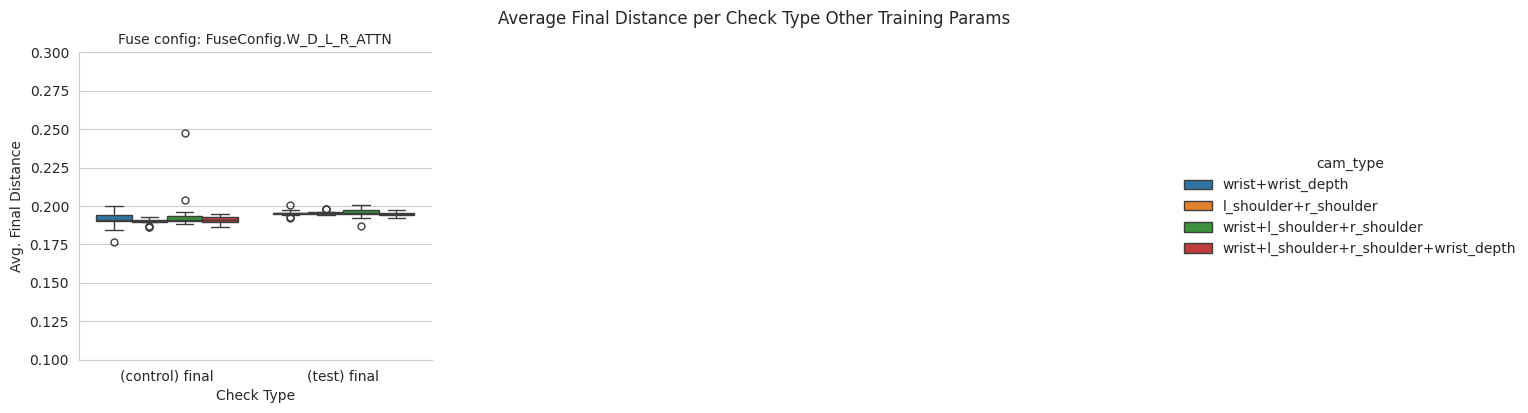

In [102]:
# Plot
g = sns.catplot(
    data=df_film_avg_long_final,
    x='condition',
    y='distance',
    hue='cam_type',
    col="config", 
    # row='epochs',
    col_wrap=3,
    kind="box",
    errorbar=None,
    # markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
)

# g.set_titles("Epochs: {row_name}, \n Fuse config: {col_name}")
g.set_titles("Fuse config: {col_name}")
g.set_axis_labels("Check Type", "Avg. Final Distance")
g.figure.suptitle("Average Final Distance per Check Type Other Training Params", y=1.02)#
g.set(ylim=(0.1, 0.3))
# savefig(f"cam-comb/reach-obs/Z-ro_random-success.png", g = g)
plt.show()


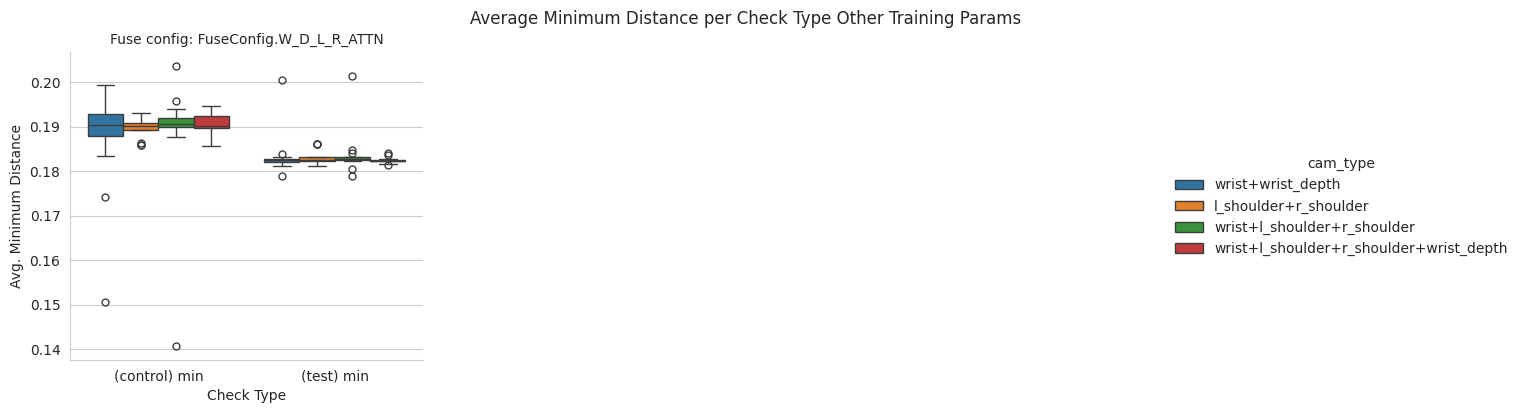

In [103]:
# Plot
g = sns.catplot(
    data=df_film_avg_long_min,
    x='condition',
    y='distance',
    hue='cam_type',
    col="config", 
    # row='epochs',
    col_wrap=3,
    kind="box",
    errorbar=None,
    # markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
)

# g.set_titles("Epochs: {row_name}, \n Fuse config: {col_name}")
g.set_titles("Fuse config: {col_name}")
g.set_axis_labels("Check Type", "Avg. Minimum Distance")
g.figure.suptitle("Average Minimum Distance per Check Type Other Training Params", y=1.02)#
# savefig(f"cam-comb/reach-obs/Z-ro_random-success.png", g = g)
plt.show()


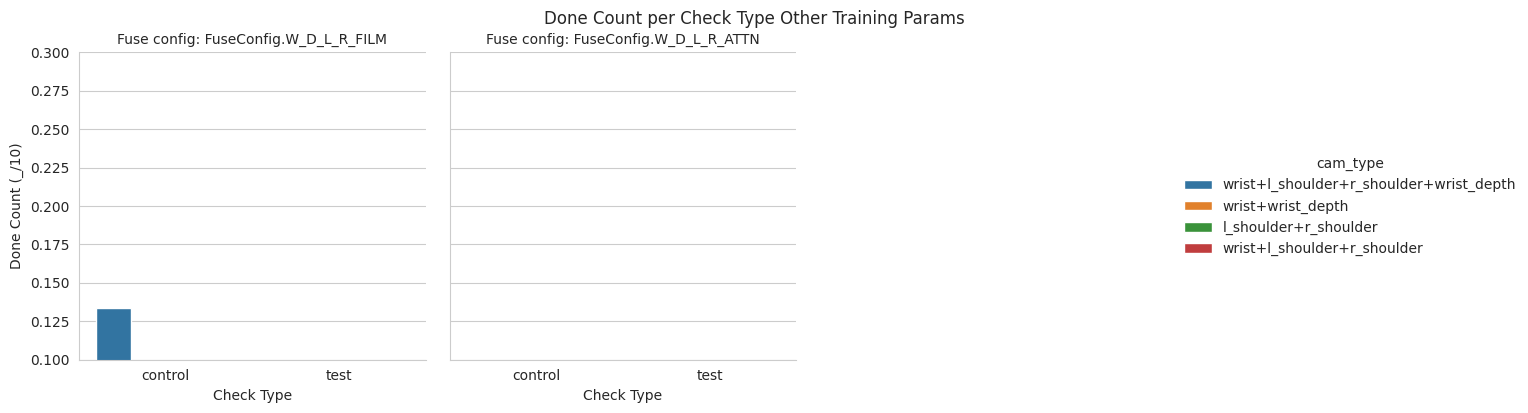

In [107]:
# Plot
g = sns.catplot(
    data=df_film_avg_dones,
    x='condition',
    y='done_count',
    hue='cam_type',
    col="config", 
    # row='epochs',
    col_wrap=3,
    kind="bar",
    errorbar=None,
    # markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
)

# g.set_titles("Epochs: {row_name}, \n Fuse config: {col_name}")
g.set_titles("Fuse config: {col_name}")
g.set_axis_labels("Check Type", "Done Count (_/10)")
g.figure.suptitle("Done Count per Check Type Other Training Params", y=1.02)#
g.set(ylim=(0.1, 0.3))
# savefig(f"cam-comb/reach-obs/Z-ro_random-success.png", g = g)
plt.show()


## Films Comparison

In [20]:
# combine_multi_file_seed(
#   configs,
#   "ZZ-films-wd",
#   "vs_random-sn",
#   "{file}-cfg:{fuse_config}-seed{seed}"
# )

df_all = pd.read_csv("ZZ-films-wd/ALLvs_random-sn.csv")
df_avg = pd.read_csv("ZZ-films-wd/vs_random-sn.csv")

df_avg_long_final, df_avg_long_min = final_and_min_melter(df_avg)

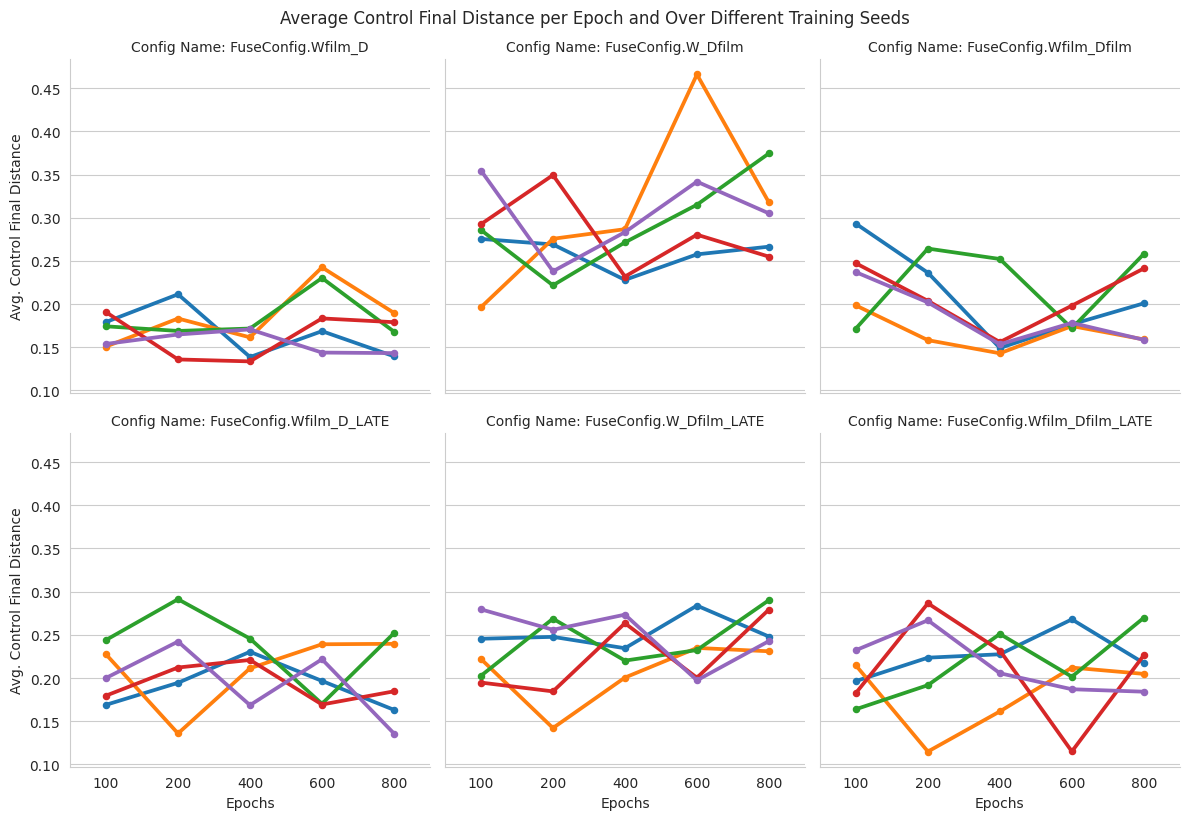

In [30]:
# Plot
g = sns.catplot(
    data=df_avg,
    x='epochs',
    y='avg_control_final_distance',
    hue='seed',
    col='config',
    col_wrap=3,
    kind="point",
    errorbar=None,
    markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
    legend = None ## its just seed
)

g.set_titles("Config Name: {col_name}")
g.set_axis_labels("Epochs", "Avg. Control Final Distance")
g.figure.suptitle("Average Control Final Distance per Epoch and Over Different Training Seeds", y=1.02)#
# savefig(f"cam-comb/reach-obs/Z-ro_random-success.png", g = g)
plt.show()


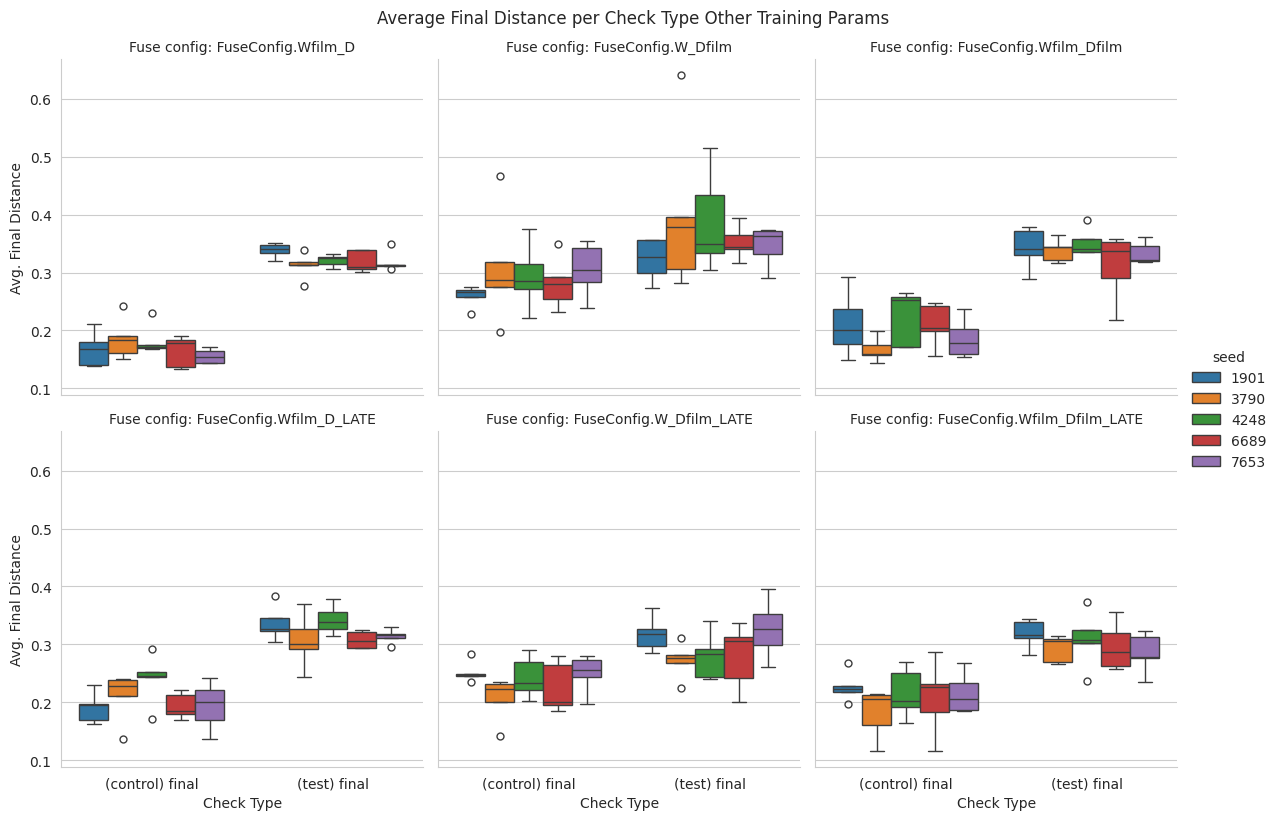

In [32]:
# Plot
g = sns.catplot(
    data=df_avg_long_final,
    x='condition',
    y='distance',
    hue='seed',
    col="config", 
    # row='epochs',
    col_wrap=3,
    kind="box",
    errorbar=None,
    # markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
)

# g.set_titles("Epochs: {row_name}, \n Fuse config: {col_name}")
g.set_titles("Fuse config: {col_name}")
g.set_axis_labels("Check Type", "Avg. Final Distance")
g.figure.suptitle("Average Final Distance per Check Type Other Training Params", y=1.02)#
# savefig(f"cam-comb/reach-obs/Z-ro_random-success.png", g = g)
plt.show()


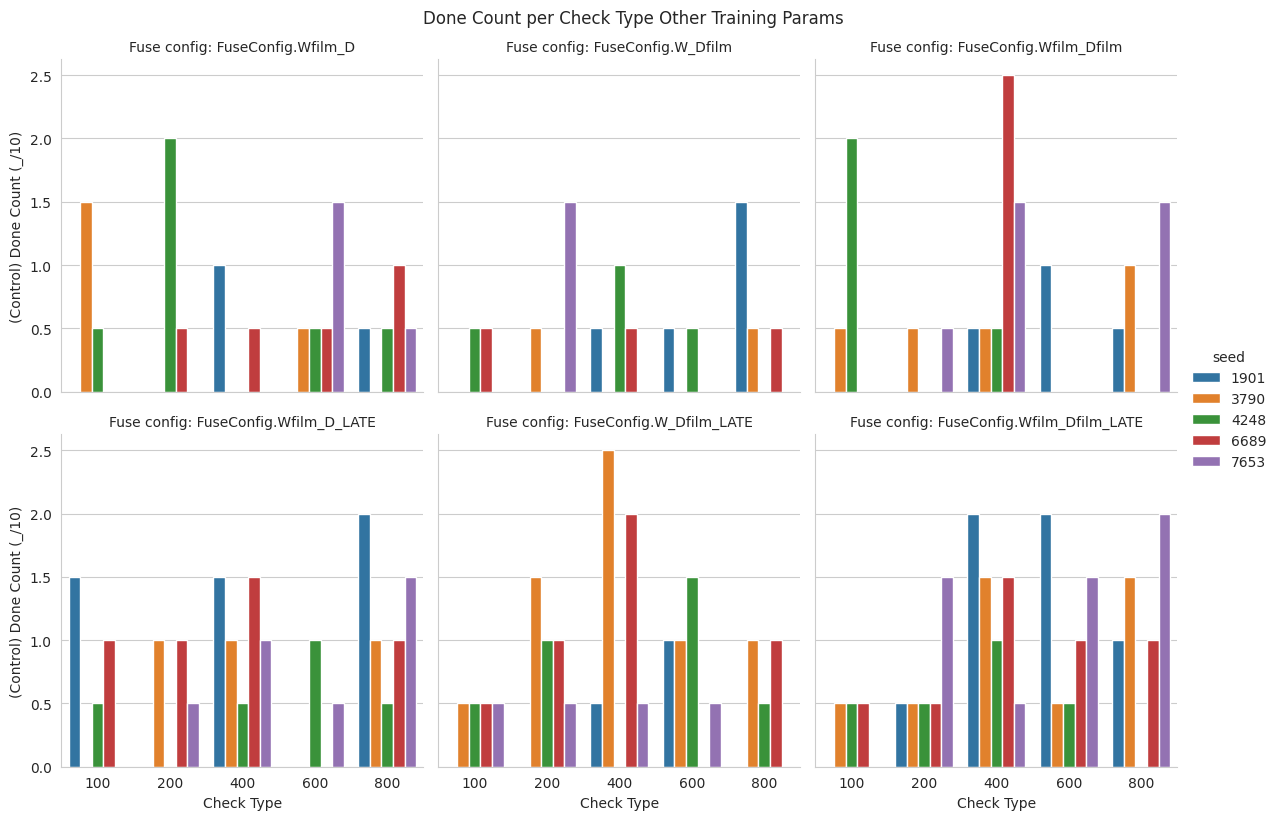

In [49]:
##NOTE: presnet this in table form i think

df_avg_dones = done_count_melter(df_avg)
# Plot
g = sns.catplot(
    data=df_avg_dones,#[df_avg_dones["condition"] == "control"],
    x='epochs',
    y='done_count',
    hue='seed',
    col="config", 
    # row='epochs',
    col_wrap=3,
    kind="bar",
    errorbar=None,
    # markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
)

# g.set_titles("Epochs: {row_name}, \n Fuse config: {col_name}")
g.set_titles("Fuse config: {col_name}")
g.set_axis_labels("Check Type", "(Control) Done Count (_/10)")
g.figure.suptitle("Done Count per Check Type Other Training Params", y=1.02)#
# savefig(f"cam-comb/reach-obs/Z-ro_random-success.png", g = g)
plt.show()


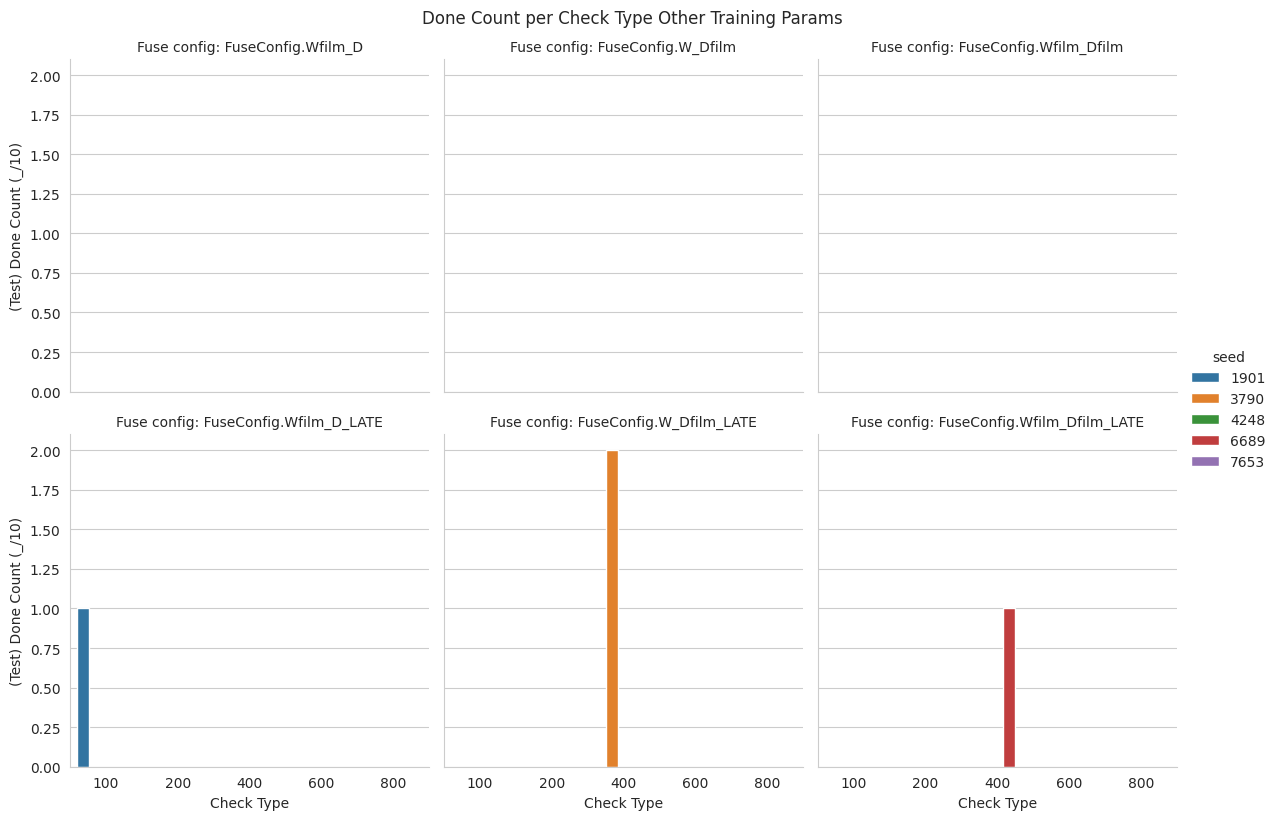

In [45]:
df_avg_dones = done_count_melter(df_avg)
# Plot
g = sns.catplot(
    data=df_avg_dones[df_avg_dones["condition"] == "test"],
    x='epochs',
    y='done_count',
    hue='seed',
    col="config", 
    # row='epochs',
    col_wrap=3,
    kind="bar",
    errorbar=None,
    # markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
)

# g.set_titles("Epochs: {row_name}, \n Fuse config: {col_name}")
g.set_titles("Fuse config: {col_name}")
g.set_axis_labels("Check Type", "(Test) Done Count (_/10)")
g.figure.suptitle("Done Count per Check Type Other Training Params", y=1.02)#
# savefig(f"cam-comb/reach-obs/Z-ro_random-success.png", g = g)
plt.show()

##NOTE: mention this as a footnote somewhere

## Big run Final


In [66]:
configs = [
  FuseConfig.WDLR,
  FuseConfig.WLR_D,
  FuseConfig.DEPTH_FEATS_GATED,
  FuseConfig.DEPTH_FEATS_ATTN,
  FuseConfig.WD_LR,
  FuseConfig.WD_LR_ATTN,
  FuseConfig.Wfilm_D,
  FuseConfig.W_Dfilm,
  FuseConfig.Wfilm_Dfilm,
  FuseConfig.W_D_L_R,
  FuseConfig.W_D_L_R_FILM,
  FuseConfig.W_D_L_R_ATTN,
]
# combine_multi_file_seed(
#   configs,
#   "ZZ-normal-then-small-final",
#   "vs_random-ns",
#   "{file}-cfg:{fuse_config}-seed{seed}"
# )

df_all = pd.read_csv("ZZ-normal-then-small-final/ALLvs_random-ns.csv")
df_avg = pd.read_csv("ZZ-normal-then-small-final/vs_random-ns.csv")

df_avg_long_final, df_avg_long_min = final_and_min_melter(df_avg)
df_avg_dones = done_count_melter(df_avg)

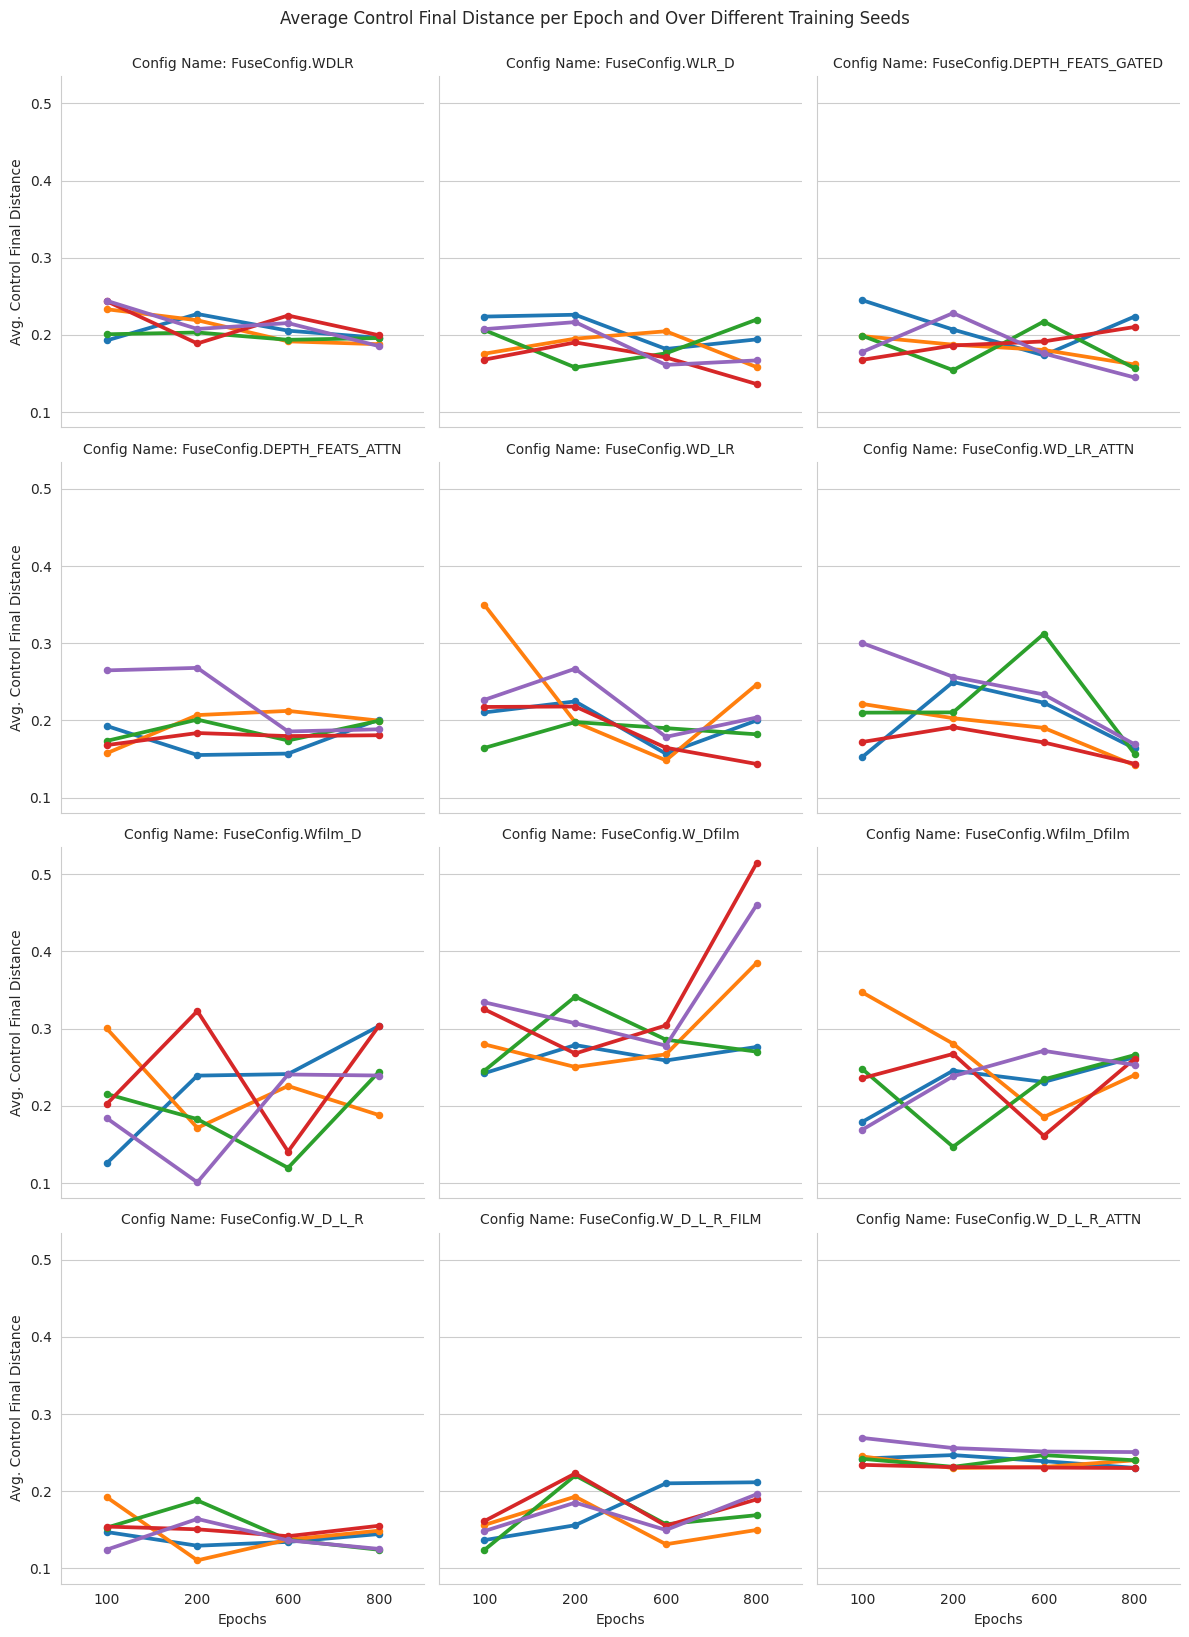

In [63]:
# Plot
g = sns.catplot(
    data=df_avg,
    x='epochs',
    y='avg_control_final_distance',
    hue='seed',
    col='config',
    col_wrap=3,
    kind="point",
    errorbar=None,
    markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
    legend = None ## its just seed
)

g.set_titles("Config Name: {col_name}")
g.set_axis_labels("Epochs", "Avg. Control Final Distance")
g.figure.suptitle("Average Control Final Distance per Epoch and Over Different Training Seeds", y=1.02)#
# savefig(f"cam-comb/reach-obs/Z-ro_random-success.png", g = g)
plt.show()


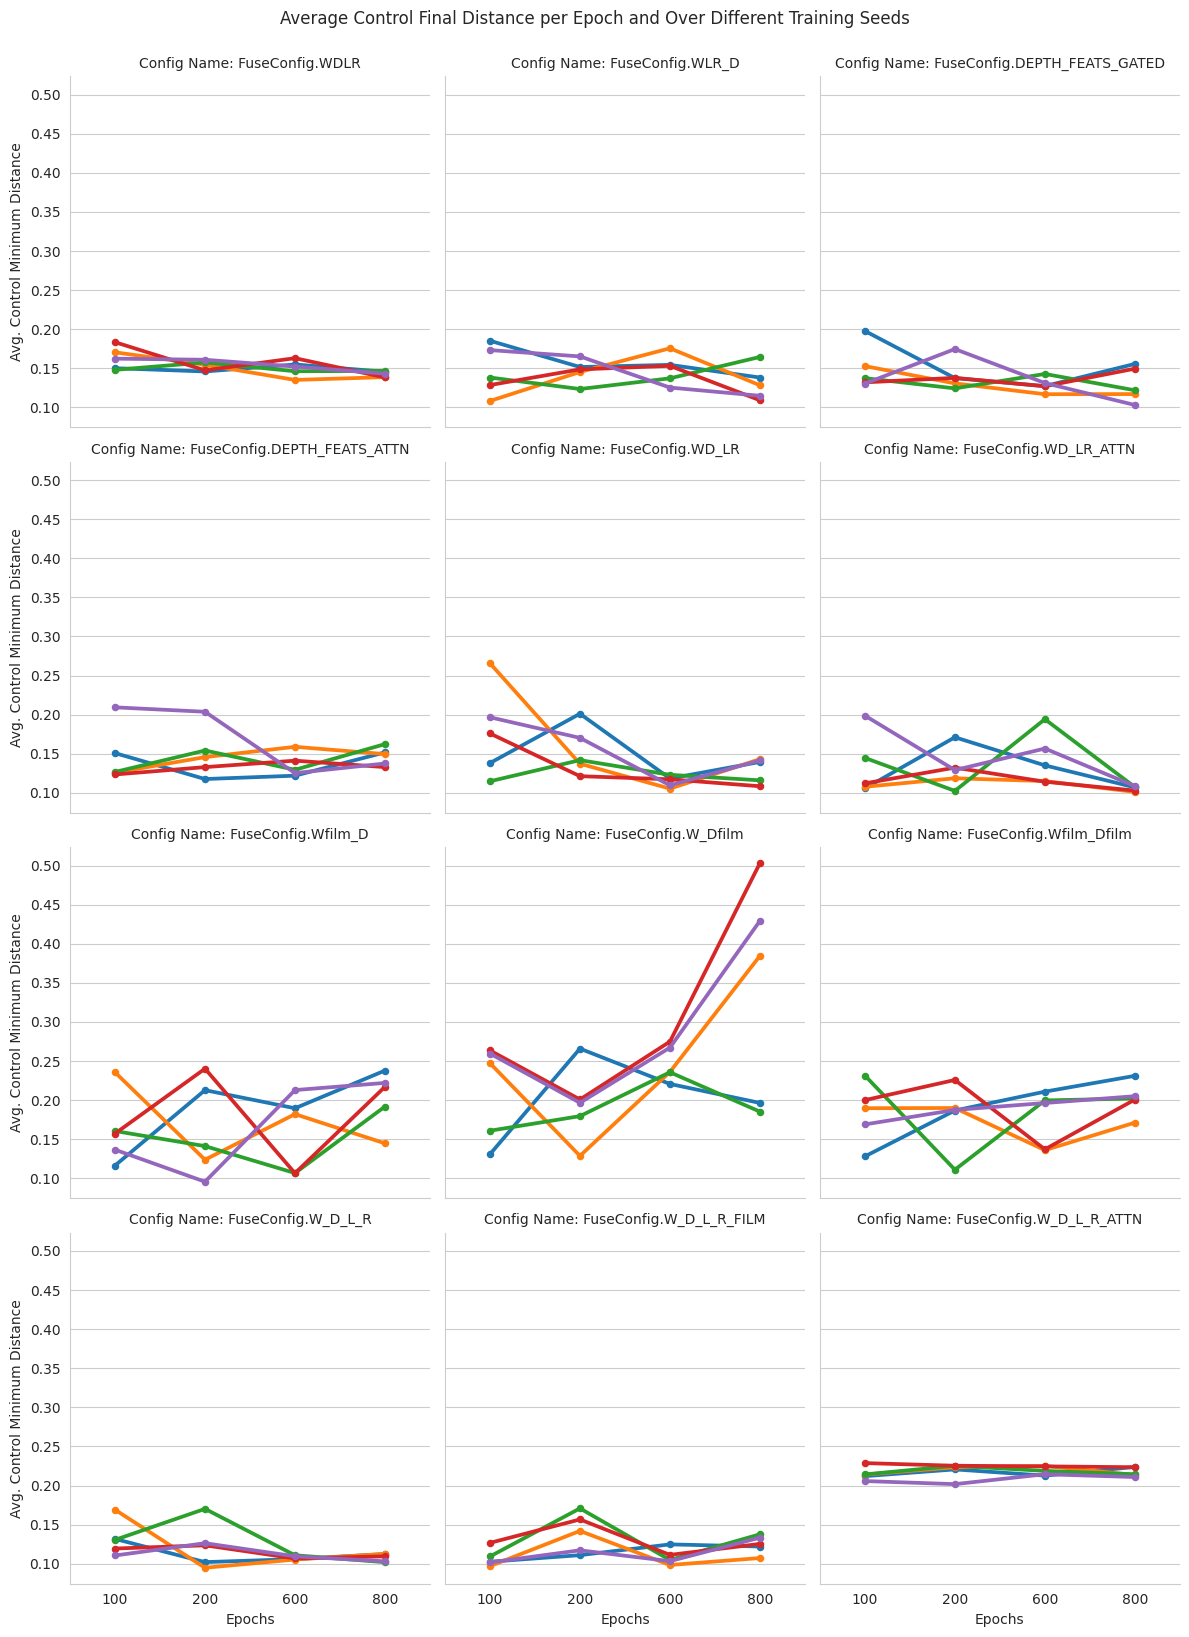

In [64]:
# Plot
g = sns.catplot(
    data=df_avg,
    x='epochs',
    y='avg_control_min_distance',
    hue='seed',
    col='config',
    col_wrap=3,
    kind="point",
    errorbar=None,
    markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
    legend = None ## its just seed
)

g.set_titles("Config Name: {col_name}")
g.set_axis_labels("Epochs", "Avg. Control Minimum Distance")
g.figure.suptitle("Average Control Final Distance per Epoch and Over Different Training Seeds", y=1.02)#
# savefig(f"cam-comb/reach-obs/Z-ro_random-success.png", g = g)
plt.show()


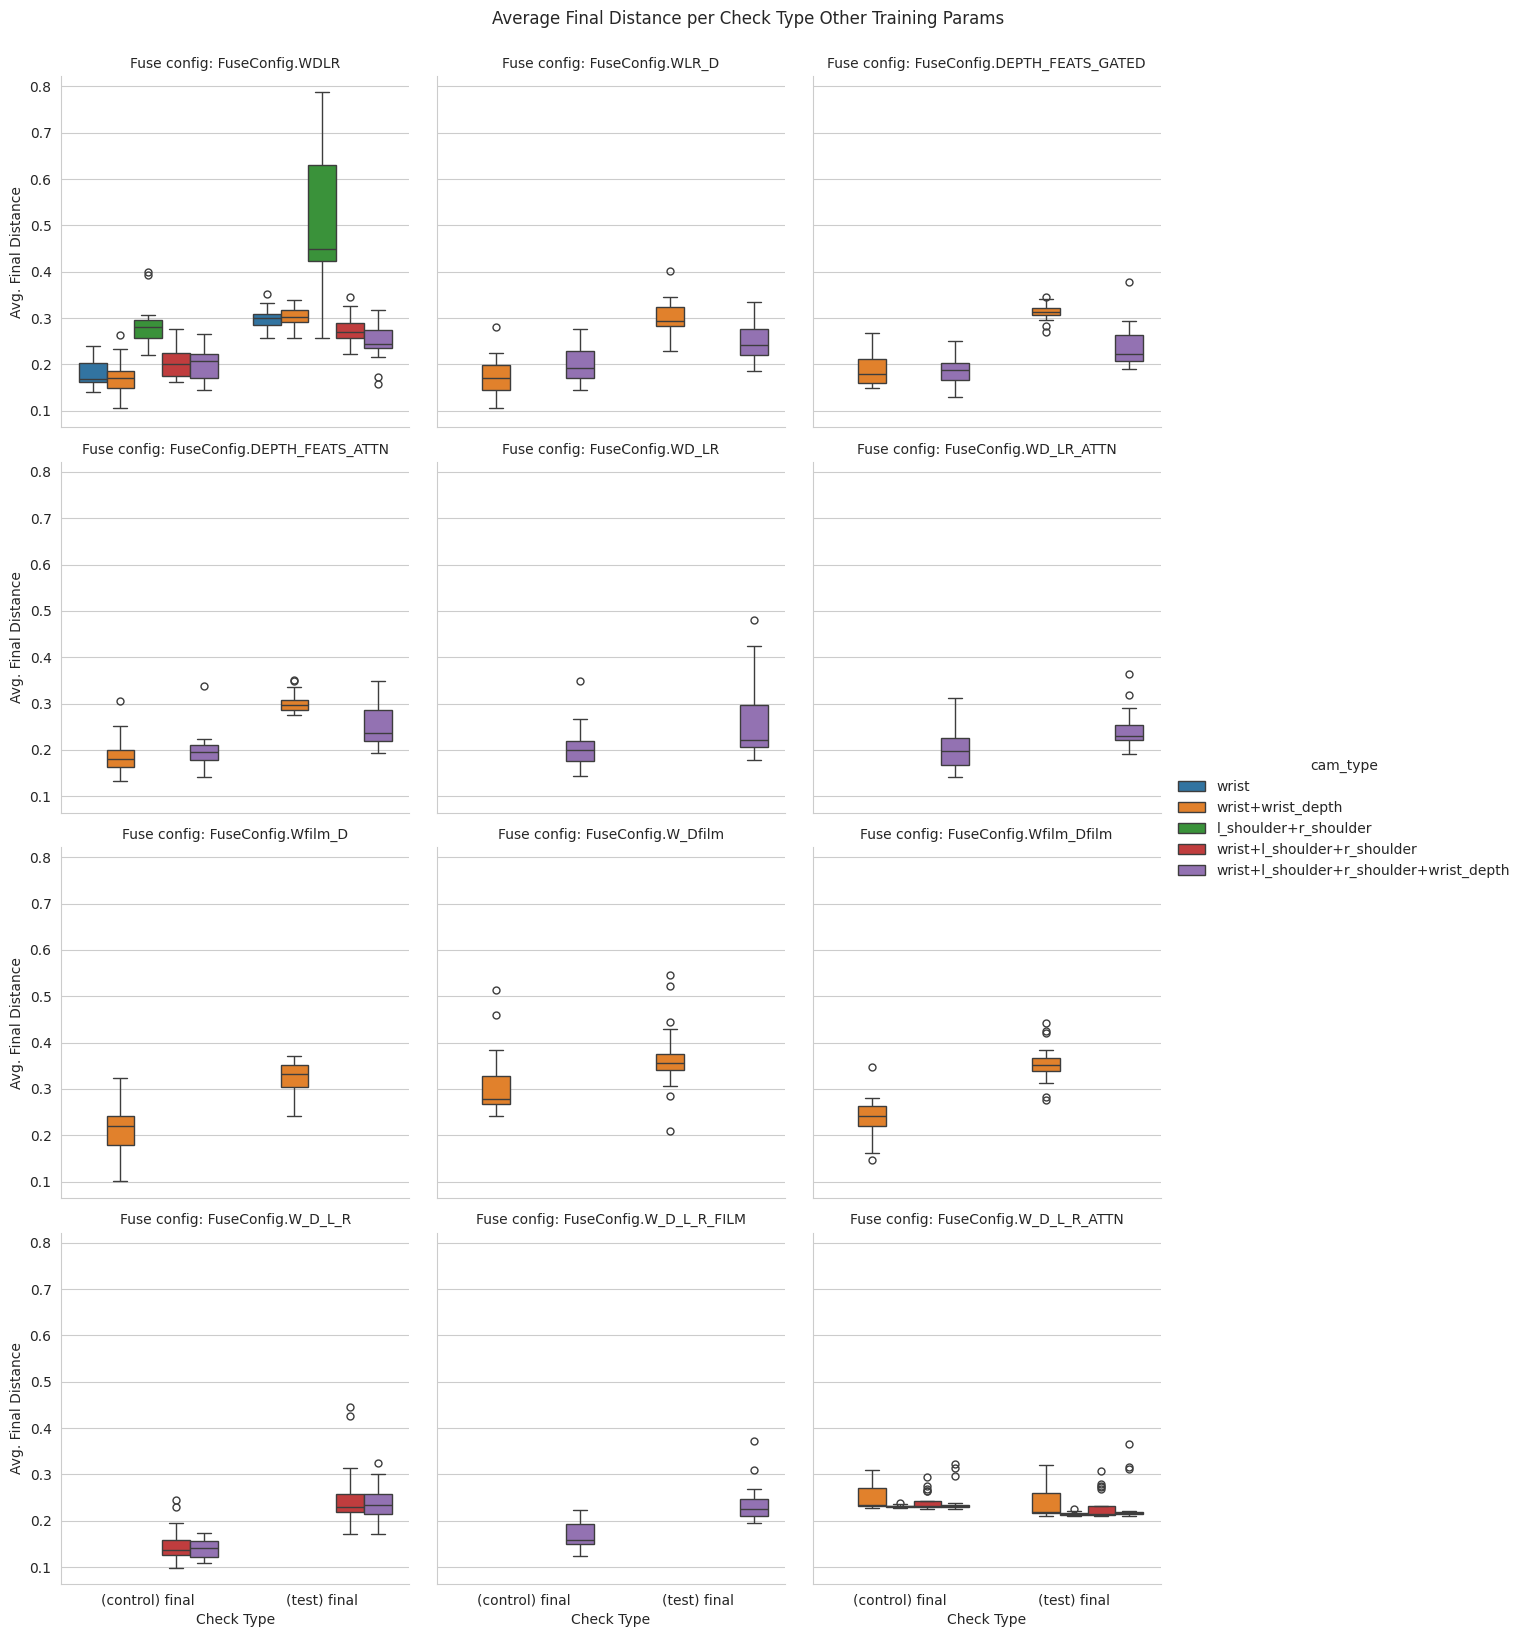

In [71]:
# Plot
g = sns.catplot(
    data=df_avg_long_final,
    x='condition',
    y='distance',
    hue='cam_type',
    col="config", 
    # row='epochs',
    col_wrap=3,
    kind="box",
    errorbar=None,
    # markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
)

# g.set_titles("Epochs: {row_name}, \n Fuse config: {col_name}")
g.set_titles("Fuse config: {col_name}")
g.set_axis_labels("Check Type", "Avg. Final Distance")
g.figure.suptitle("Average Final Distance per Check Type Other Training Params", y=1.02)#
# savefig(f"cam-comb/reach-obs/Z-ro_random-success.png", g = g)
plt.show()


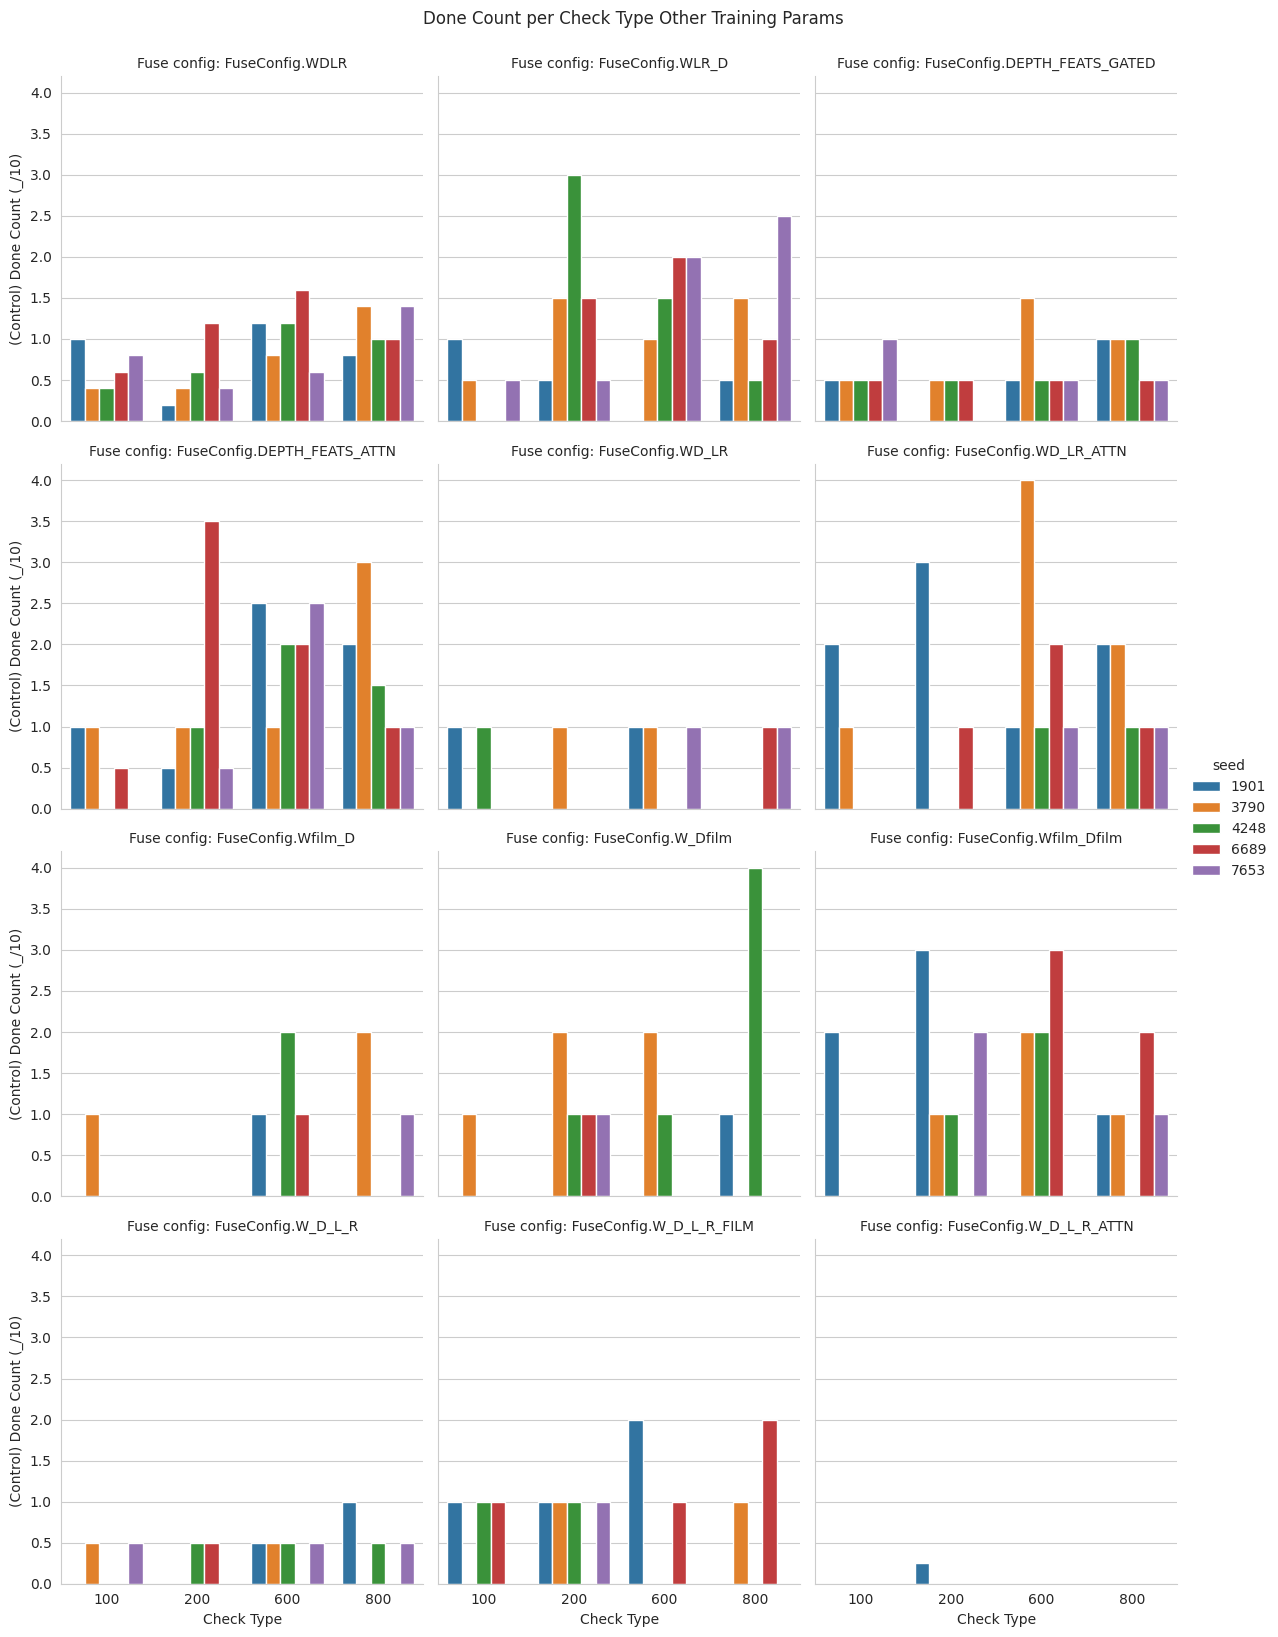

In [70]:
##NOTE: presnet this in table form i think

df_avg_dones = done_count_melter(df_avg)
# Plot
g = sns.catplot(
    data=df_avg_dones[df_avg_dones["condition"] == "control"],
    x='epochs',
    y='done_count',
    hue='seed',
    col="config", 
    # row='epochs',
    col_wrap=3,
    kind="bar",
    errorbar=None,
    # markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
)

# g.set_titles("Epochs: {row_name}, \n Fuse config: {col_name}")
g.set_titles("Fuse config: {col_name}")
g.set_axis_labels("Check Type", "(Control) Done Count (_/10)")
g.figure.suptitle("Done Count per Check Type Other Training Params", y=1.02)#
# savefig(f"cam-comb/reach-obs/Z-ro_random-success.png", g = g)
plt.show()


## LSTM run (finally)